In [1]:
# [ADDED] worked example – run this cell
# Environment check – run in each environment and include the output in your report
import sys, platform, importlib
print("Python version :", sys.version.split()[0])
print("Executable     :", sys.executable)
print("Operating sys. :", platform.system(), platform.release())
for pkg in ["numpy", "pandas", "matplotlib", "sklearn", "statsmodels", "ISLP"]:
    try:
        m = importlib.import_module(pkg)
        print(f"{pkg:<12} {getattr(m, '__version__', 'installed')}")
    except ImportError:
        print(f"{pkg:<12} NOT INSTALLED – run the Setup cell / pip install ISLP")

Python version : 3.12.10
Executable     : e:\lab-statistical-learning\.venv\Scripts\python.exe
Operating sys. : Windows 11
numpy        2.5.3
pandas       2.3.3
matplotlib   3.11.2
sklearn      1.9.1
statsmodels  0.15.0
ISLP         0.4.1


In [2]:
# [ADDED]
# 0. Setup – run this cell first (installs missing packages and fetches data files).
# On Google Colab the first run takes about 1 minute. If Colab asks you to
# "Restart session", accept, then run this cell once more.
import sys, os, subprocess, importlib.util, urllib.request

def ensure(module, pip_name=None):
    """pip-install a package only if it cannot be imported yet."""
    if importlib.util.find_spec(module) is None:
        print(f"Installing {pip_name or module} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or module], check=True)

ensure("ISLP", "ISLP")

# data files used by this lab (downloaded from the official ISLP_labs repository if missing)
BASE_URL = "https://raw.githubusercontent.com/intro-stat-learning/ISLP_labs/v2.2.3/"
ASSETS_DIR = "assets"

os.makedirs(ASSETS_DIR, exist_ok=True)

for fname in ['Auto.csv', 'Auto.data']:
    path = os.path.join(ASSETS_DIR, fname)
    if not os.path.exists(path):
        urllib.request.urlretrieve(BASE_URL + fname, path)

print("Setup complete – Python", sys.version.split()[0])


Setup complete – Python 3.12.10


In [3]:
# ✍️ Task 0 – environment check in two environments – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
full_name = "Lê Thái Đức Tùng"     # <- replace with your full name
print(f"Hello, {full_name}! My statistical-learning environment works.")


Hello, Lê Thái Đức Tùng! My statistical-learning environment works.


In [4]:
import numpy as np

# <span style="color:red">5. Exercises</span>

<span style="color:red">Solve the exercises in the ✍️ cells of the notebook. For every exercise write **code + output + 1–3 sentences of interpretation**. Exercises 1–7 are compulsory; 8–9 are challenge (bonus) exercises.</span>

## <span style="color:red">Exercise 1 – NumPy warm-up</span>

- <span style="color:red">**(a)** Create the vector $v = (2, 4, 6, \dots, 40)$ with `np.arange()` and reshape it into a $4\times5$ matrix `M`.</span>
- <span style="color:red">**(b)** Print `M.shape`, `M.ndim`, `M.dtype` and the transpose `M.T`.</span>
- <span style="color:red">**(c)** Extract the second row, the last column and the sub-matrix of rows 2–3 and columns 1–3 (1-based counting) using slices.</span>
- <span style="color:red">**(d)** Compute row means and column standard deviations with the `axis` argument.</span>
- <span style="color:red">**(e)** Set `B = M[:2, :2]`, then `B[0, 0] = -1`. Did `M` change? Repeat with `B = M[:2, :2].copy()` and explain the difference.</span>

In [5]:
# ✍️ Exercise 1 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
import numpy as np
v = np.arange(2, 42, 2)          # TODO (a): np.arange(...)
M = v.reshape(4, 5)              # TODO (a): v.reshape(...)

In [6]:
M

array([[ 2,  4,  6,  8, 10],
       [12, 14, 16, 18, 20],
       [22, 24, 26, 28, 30],
       [32, 34, 36, 38, 40]])

In [7]:
if M is not None:
    print(M.shape, M.ndim, M.dtype)   # (b)
    # TODO (c)–(e)
    # (c)
    print("Second row:", M[1, :])
    print("Last column:", M[:,-1])
    print("Submatrix 2-3 x 1-3:\n", M[1:3,0:3])


(4, 5) 2 int64
Second row: [12 14 16 18 20]
Last column: [10 20 30 40]
Submatrix 2-3 x 1-3:
 [[12 14 16]
 [22 24 26]]


In [8]:
if M is not None:
    # (d)
    print(np.mean(M, axis=1))
    print(np.std(M, axis=0))

[ 6. 16. 26. 36.]
[11.18033989 11.18033989 11.18033989 11.18033989 11.18033989]


In [9]:
# (e)
v = np.arange(2, 42, 2)          # TODO (a): np.arange(...)
M = v.reshape(4, 5)              # TODO (a): v.reshape(...)
B = M[:2, :2]
B[0, 0] = -1

print(B, "\n\n", M)

[[-1  4]
 [12 14]] 

 [[-1  4  6  8 10]
 [12 14 16 18 20]
 [22 24 26 28 30]
 [32 34 36 38 40]]


In [10]:
v = np.arange(2, 42, 2)          # TODO (a): np.arange(...)
M = v.reshape(4, 5)              # TODO (a): v.reshape(...)
B = M[:2, :2].copy()
B[0, 0] = -1

print(B, "\n\n", M)

[[-1  4]
 [12 14]] 

 [[ 2  4  6  8 10]
 [12 14 16 18 20]
 [22 24 26 28 30]
 [32 34 36 38 40]]


## <span style="color:red">Exercise 2 – Random numbers, correlation and a saved figure</span>

- <span style="color:red">**(a)** Create `rng = np.random.default_rng(2026)` and simulate $n = 100$ values $x_i \sim N(0,1)$ and $\varepsilon_i \sim N(0, 0.5^2)$.</span>
- <span style="color:red">**(b)** Compute $y_i = 2 + 3x_i + \varepsilon_i$. What is the correlation between $x$ and $y$ (`np.corrcoef`)?</span>
- <span style="color:red">**(c)** Draw a scatter plot of $y$ against $x$ with axis labels and a title, add the true line $y = 2 + 3x$ in red, and save the figure as `ex2_scatter.png` (dpi = 150).</span>
- <span style="color:red">**(d)** Re-run the cell: are the numbers the same? What happens if you remove the seed?</span>

In [11]:
# ✍️ Exercise 2 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
import numpy as np
from matplotlib.pyplot import subplots

In [12]:
n = 100
rng = np.random.default_rng(2026)
x = rng.standard_normal(n)
eps = rng.normal(loc=0, scale=0.5, size=n)        # TODO (a)

In [13]:
y = 2 + 3*x + eps          # TODO (b)
# TODO (b): print(np.corrcoef(x, y))
print(np.corrcoef(x, y))

[[1.       0.982033]
 [0.982033 1.      ]]


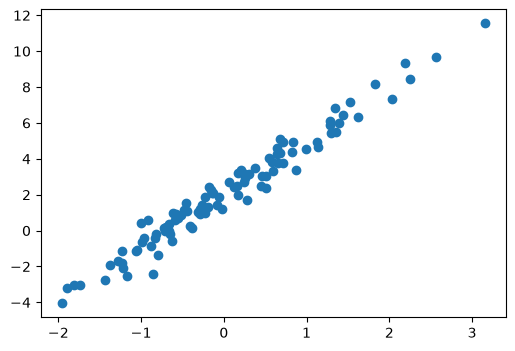

In [14]:
# TODO (c): fig, ax = subplots(figsize=(6, 4)); ax.scatter(...); fig.savefig("ex2_scatter.png", dpi=150)
fig, ax = subplots(figsize=(6, 4))
ax.scatter(x, y)
fig.savefig("out/ex2_scatter.png", dpi=150)

[[1.         0.98753087]
 [0.98753087 1.        ]]


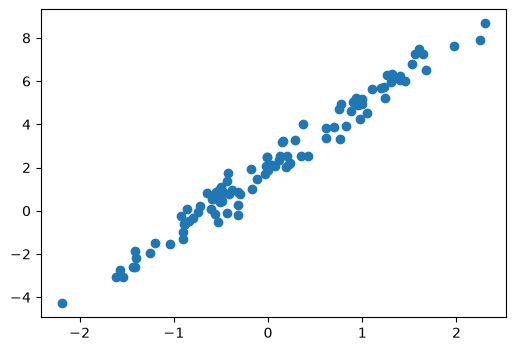

In [15]:
# (d)
rng = np.random.default_rng(1000)
x = rng.standard_normal(n)
eps = rng.normal(loc=0, scale=0.5, size=n)
y = 2 + 3*x + eps
print(np.corrcoef(x, y))
fig, ax = subplots(figsize=(6, 4))
ax.scatter(x, y)

## <span style="color:red">Exercise 3 – Cleaning the `Auto` data</span>

- <span style="color:red">**(a)** Read `Auto.data` with `pd.read_csv(..., sep=r"\s+", na_values=["?"])`. How many rows contain at least one missing value? Remove them with `dropna()`.</span>
- <span style="color:red">**(b)** Which variables are **quantitative** and which are **qualitative**? Convert `origin` into a categorical variable with the labels *America* (1), *Europe* (2), *Japan* (3) – hint: `Auto["origin"].map({1: "America", 2: "Europe", 3: "Japan"})`.</span>
- <span style="color:red">**(c)** For every quantitative variable report its **range, mean and standard deviation** in one table (`describe()` or `agg(["min", "max", "mean", "std"])`).</span>

In [16]:
# ✍️ Exercise 3 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
import pandas as pd
Auto_raw = pd.read_csv("assets/Auto.data", sep=r"\s+", na_values=["?"])
print("Shape of Auto.data:", Auto_raw.shape)
n_missing = Auto_raw.isna().any(axis=1).sum()   # TODO (a): number of rows with at least one NaN
print("Number of Missing Row:", n_missing)
Auto_clean = Auto_raw.dropna()  # TODO (a): Auto_raw.dropna()

Shape of Auto.data: (397, 9)
Number of Missing Row: 5


In [17]:
# TODO (b)
print("Print types of each column:\n", Auto_raw.dtypes)

Print types of each column:
 mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object


In [18]:
print("Before: ", Auto_raw["origin"].unique())
Auto_raw["origin"].map({1: "America", 2: "Europe", 3: "Japan"})

Before:  [1 3 2]


0      America
1      America
2      America
3      America
4      America
        ...   
392    America
393     Europe
394    America
395    America
396    America
Name: origin, Length: 397, dtype: object

In [19]:
# TODO (c)
for c in Auto_raw.columns:
    print("Describe of", c ,":")
    print(Auto_raw[c].describe())
    print()

Describe of mpg :
count    397.000000
mean      23.515869
std        7.825804
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

Describe of cylinders :
count    397.000000
mean       5.458438
std        1.701577
min        3.000000
25%        4.000000
50%        4.000000
75%        8.000000
max        8.000000
Name: cylinders, dtype: float64

Describe of displacement :
count    397.000000
mean     193.532746
std      104.379583
min       68.000000
25%      104.000000
50%      146.000000
75%      262.000000
max      455.000000
Name: displacement, dtype: float64

Describe of horsepower :
count    392.000000
mean     104.469388
std       38.491160
min       46.000000
25%       75.000000
50%       93.500000
75%      126.000000
max      230.000000
Name: horsepower, dtype: float64

Describe of weight :
count     397.000000
mean     2970.261965
std       847.904119
min      1613.000000
25%      2223.000000
50%      2

## <span style="color:red">Exercise 4 – Subsetting rows with `iloc[]`</span>

<span style="color:red">Using the cleaned data from Exercise 3, remove the **10th through 85th observations** (1-based) and recompute the range, mean and standard deviation of each quantitative variable. Which statistics change the most? Why might that be?</span>

In [20]:
import pandas as pd
Auto_raw = pd.read_csv("assets/Auto.data", sep=r"\s+", na_values=["?"])
Auto_clean = Auto_raw.dropna()

In [21]:
# ✍️ Exercise 4 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
# TODO: keep = np.r_[0:9, 85:len(Auto_clean)]   then   Auto_sub = Auto_clean.iloc[keep]
keep = np.r_[0:9, 85:len(Auto_clean)]   
Auto_sub = Auto_clean.iloc[keep]
print(Auto_clean.shape, " -> ", Auto_sub.shape)

(392, 9)  ->  (316, 9)


In [22]:
quant = ["mpg", "cylinders", "displacement", "horsepower",
         "weight", "acceleration", "year"] 
before = Auto_clean[quant].agg(["min", "max", "mean", "std"]).T
after  = Auto_sub[quant].agg(["min", "max", "mean", "std"]).T

In [23]:
pd.concat({"before": before, "after": after}, axis=1).round(2)

before                            after                         
                 min     max     mean     std     min     max     mean     std
mpg              9.0    46.6    23.45    7.81    11.0    46.6    24.40    7.87
cylinders        3.0     8.0     5.47    1.71     3.0     8.0     5.37    1.65
displacement    68.0   455.0   194.41  104.64    68.0   455.0   187.24   99.68
horsepower      46.0   230.0   104.47   38.49    46.0   230.0   100.72   35.71
weight        1613.0  5140.0  2977.58  849.40  1649.0  4997.0  2935.97  811.30
acceleration     8.0    24.8    15.54    2.76     8.5    24.8    15.73    2.69
year            70.0    82.0    75.98    3.68    70.0    82.0    77.15    3.11

In [24]:
compare = pd.concat({"mean before": before["mean"], "mean after": after["mean"]}, axis=1).round(2)
compare["mean change (%)"] = ((after["mean"] - before["mean"]) / before["mean"] * 100).round(1)
compare

,mean before,mean after,mean change (%)
mpg,23.45,24.40,4.1
cylinders,5.47,5.37,-1.8
displacement,194.41,187.24,-3.7
horsepower,104.47,100.72,-3.6
weight,2977.58,2935.97,-1.4
acceleration,15.54,15.73,1.2
year,75.98,77.15,1.5


## <span style="color:red">Exercise 5 – Graphical exploration</span>

- <span style="color:red">**(a)** Produce a scatter-plot matrix of `mpg`, `displacement`, `horsepower`, `weight` and `acceleration` (`pd.plotting.scatter_matrix`).</span>
- <span style="color:red">**(b)** Draw side-by-side box plots of `mpg` by `origin` and by `cylinders`.</span>
- <span style="color:red">**(c)** Write **three findings** in the work area. Which variables look useful for **predicting `mpg`**, and is the relationship linear?</span>

In [25]:
# ✍️ Exercise 5 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
from matplotlib.pyplot import subplots

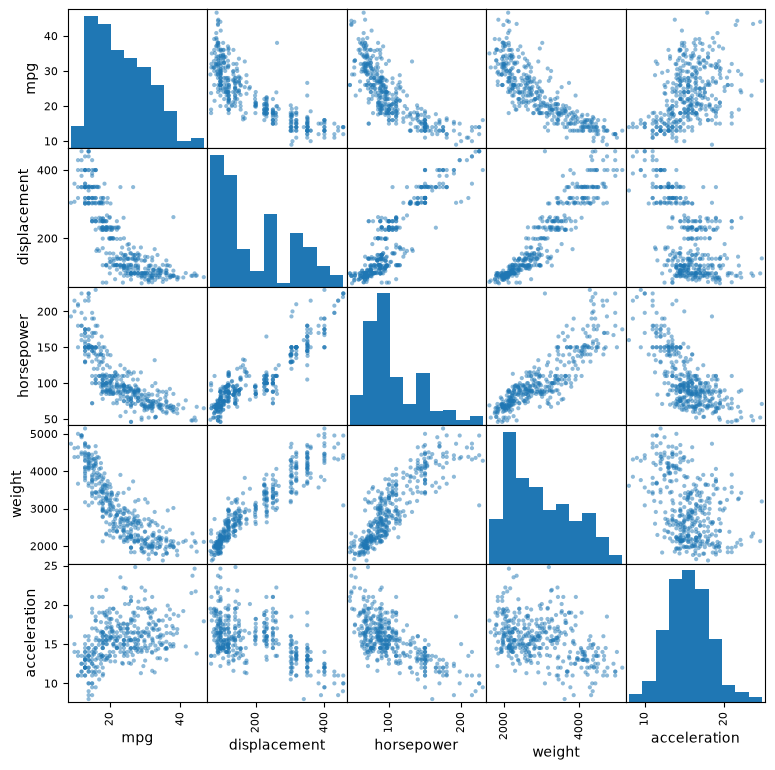

In [26]:
# TODO (a): pd.plotting.scatter_matrix(Auto_clean[[...]], figsize=(9, 9));
pd.plotting.scatter_matrix(Auto_clean[["mpg", "displacement",
                                        "horsepower", "weight",
                                        "acceleration"]], figsize=(9, 9));

<Axes: title={'center': 'mpg'}, xlabel='cylinders'>

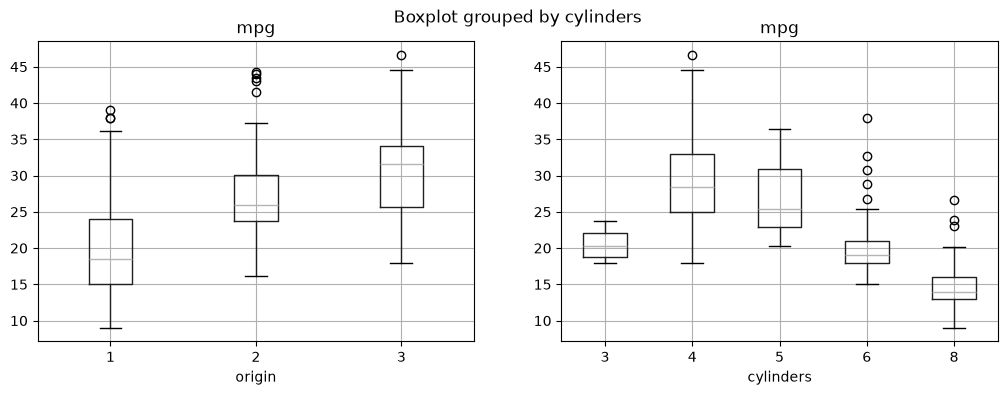

In [27]:
# TODO (b): fig, axes = subplots(1, 2, figsize=(12, 4)); Auto_clean.boxplot("mpg", by="origin", ax=axes[0]); ...
fig, axes = subplots(1, 2, figsize=(12, 4))
Auto_clean.boxplot("mpg", by="origin", ax=axes[0])
Auto_clean.boxplot("mpg", by="cylinders", ax=axes[1])

In [28]:
# TODO (c):
cols = ["mpg", "displacement", "horsepower", "weight", "acceleration"]

corr_mpg = Auto_clean[cols].corr()["mpg"].sort_values()
corr_mpg.round(2).head(3) # <---- This is three finding

weight         -0.83
displacement   -0.81
horsepower     -0.78
Name: mpg, dtype: float64

## <span style="color:red">Exercise 6 – The `College` data set</span>

<span style="color:red">The `College` data (777 US colleges) is available as `load_data("College")` from `ISLP`.</span>

- <span style="color:red">**(a)** Load it and print the first 5 rows and `College.describe()`.</span>
- <span style="color:red">**(b)** How many colleges are **private**?</span>
- <span style="color:red">**(c)** Create a new qualitative variable `Elite` that is `"Yes"` when more than 50% of new students come from the top 10% of their high-school class (`Top10perc > 50`). How many elite colleges are there?</span>
- <span style="color:red">**(d)** Draw box plots of `Outstate` (out-of-state tuition) versus `Private` and versus `Elite`.</span>
- <span style="color:red">**(e)** Make a $2 \times 2$ grid of histograms of four quantitative variables with different numbers of bins. Summarise what you see.</span>

In [29]:
# ✍️ Exercise 6 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
from ISLP import load_data
College = load_data("College")
print(College.shape)

(777, 18)


In [30]:
# TODO (a):
College.head(5)

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [31]:
College.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [32]:
College["Private"].dtype

CategoricalDtype(categories=['No', 'Yes'], ordered=False, categories_dtype=object)

In [33]:
# (b):
len(College.loc[College["Private"] == "Yes"])

565

In [34]:
# (c):
College["Elite"] = np.where(College["Top10perc"] > 50, "Yes", "No")
College["Elite"]

0       No
1       No
2       No
3      Yes
4       No
      ... 
772     No
773     No
774     No
775    Yes
776     No
Name: Elite, Length: 777, dtype: object

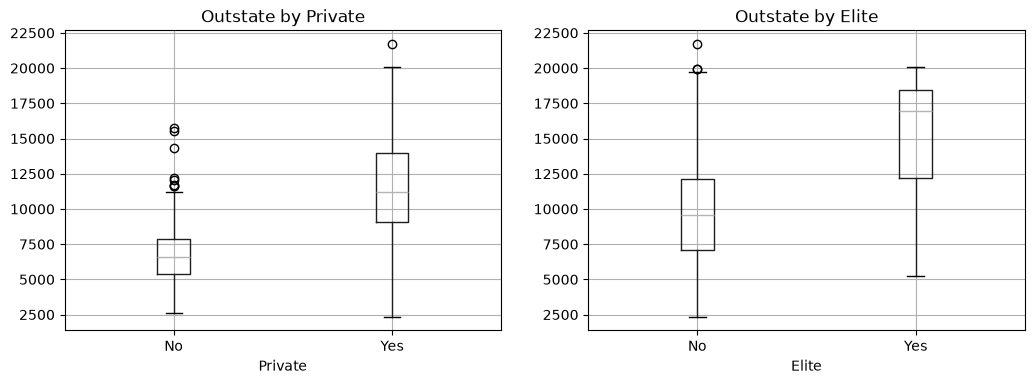

In [35]:
# (d):
fig, axes = subplots(1, 2, figsize=(12, 4))
College.boxplot("Outstate", by="Private", ax=axes[0])
College.boxplot("Outstate", by="Elite", ax=axes[1])
axes[0].set_title("Outstate by Private")
axes[1].set_title("Outstate by Elite")
fig.suptitle("");

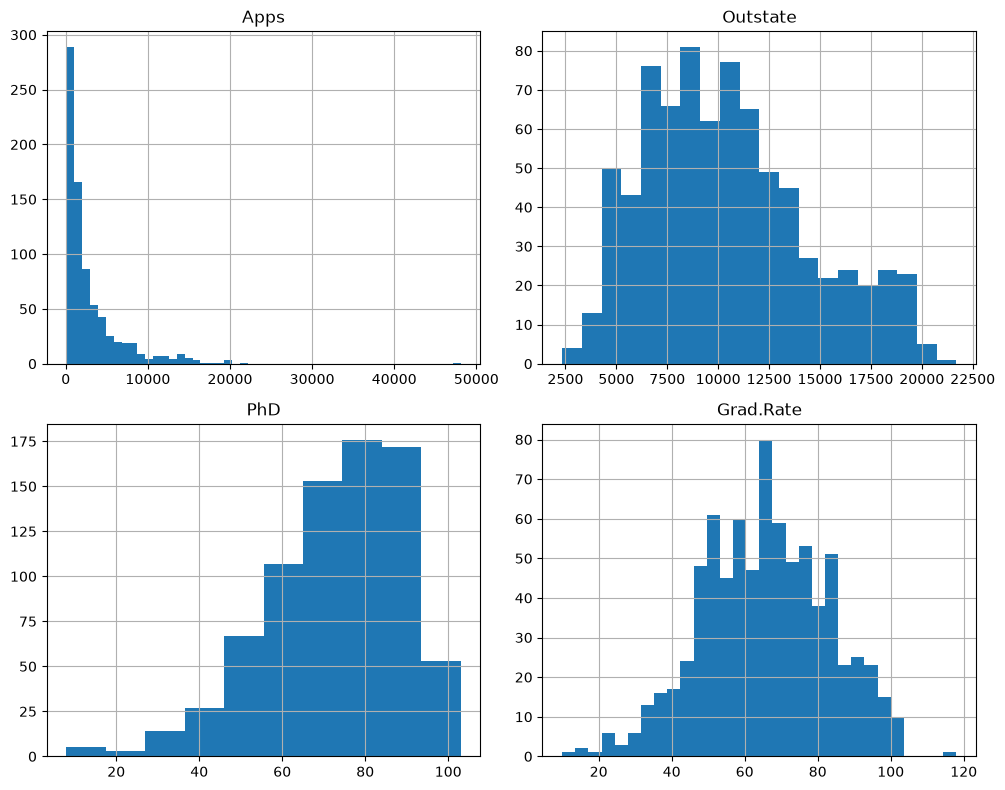

In [36]:
# (e):
fig, axes = subplots(2, 2, figsize=(10, 8))

College.hist("Apps",      bins=50, ax=axes[0, 0])
College.hist("Outstate",  bins=20, ax=axes[0, 1])
College.hist("PhD",       bins=10, ax=axes[1, 0])
College.hist("Grad.Rate", bins=30, ax=axes[1, 1])

fig.tight_layout()

## <span style="color:red">Exercise 7 – Loops and string formatting</span>

<span style="color:red">Write a `for` loop over the quantitative columns of `Auto_clean` that prints one formatted line per variable, for example</span>

<span style="color:red">*(added)*</span>
```text
horsepower   mean = 104.47  sd =  38.49  above-mean share = 37.0%
```

<span style="color:red">Use an f-string with field widths (`{name:<12}`), two decimals (`{value:.2f}`) and a percentage (`{share:.1%}`).</span>

In [37]:
import pandas as pd
Auto_raw = pd.read_csv("assets/Auto.data", sep=r"\s+", na_values=["?"])
Auto_clean = Auto_raw.dropna()

In [38]:
# ✍️ Exercise 7 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
quantitative = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "year"]
for col in quantitative:
    m     = Auto_clean[col].mean()
    sd    = Auto_clean[col].std()
    share = (Auto_clean[col] > m).mean()
    print(col, " mean =", m,
               "sd =", sd,
               "above mean share =", share) 

mpg  mean = 23.445918367346938 sd = 7.8050074865717995 above mean share = 0.4744897959183674
cylinders  mean = 5.471938775510204 sd = 1.7057832474527845 above mean share = 0.4744897959183674
displacement  mean = 194.41198979591837 sd = 104.64400390890466 above mean share = 0.4336734693877551
horsepower  mean = 104.46938775510205 sd = 38.49115993282849 above mean share = 0.37755102040816324
weight  mean = 2977.5841836734694 sd = 849.4025600429492 above mean share = 0.4336734693877551
acceleration  mean = 15.541326530612244 sd = 2.758864119188082 above mean share = 0.45663265306122447
year  mean = 75.9795918367347 sd = 3.6837365435778295 above mean share = 0.5408163265306123


## <span style="color:red">Challenge exercises (optional, bonus)</span>

### <span style="color:red">Exercise 8 – Estimating bias and variance by simulation</span>

<span style="color:red">Use the set-up of Worked Example 1. Fix the test point $x_0 = 1$. For each degree $d \in \{1, 3, 5, 10, 15\}$ repeat 200 times: draw a new training set of size 60, fit the polynomial and store $\hat f(x_0)$. Estimate $\mathrm{Bias}^2 = (\overline{\hat f(x_0)} - f(x_0))^2$ and $\mathrm{Var}(\hat f(x_0))$ and plot both against $d$. Do the curves agree with the theory?</span>

In [39]:
import numpy as np
import warnings
from matplotlib.pyplot import subplots
warnings.simplefilter("ignore")

In [40]:
rng = np.random.default_rng(2026)
f_true = lambda x: np.sin(2 * x) + 0.5 * x     # công thức "thật"
n_train, sigma = 60, 0.4

In [41]:
# ✍️ Exercise 8 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
x0, n_rep = 1.0, 200
results = {}
for d in [1, 3, 5, 10, 15]:
    preds = []
    for r in range(n_rep):
        x_tr = rng.uniform(-3, 3, n_train)
        y_tr = f_true(x_tr) + rng.normal(0, sigma, n_train)
        coef = np.polyfit(x_tr, y_tr, deg=d)
        preds.append(np.polyval(coef, x0))
    preds = np.array(preds)
    bias2 = (preds.mean() - f_true(x0))**2
    variance = preds.var()
    results[d] = (bias2, variance)

print(results)

{1: (np.float64(1.156080033348301), np.float64(0.012152299462332056)), 3: (np.float64(0.45406061881847887), np.float64(0.029004174444838843)), 5: (np.float64(0.00817433176251467), np.float64(0.014924970234291592)), 10: (np.float64(0.00016303941247180725), np.float64(0.02500386434907387)), 15: (np.float64(2.471366300643694e-06), np.float64(0.044772325150118204))}


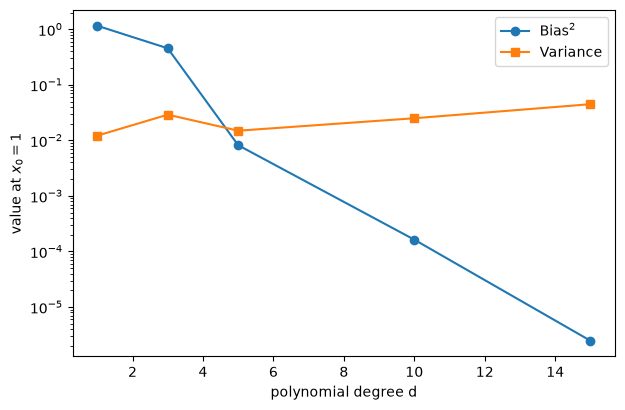

In [42]:
degs = list(results)
fig, ax = subplots(figsize=(7, 4.5))
ax.plot(degs, [results[d][0] for d in degs], 'o-', label='Bias$^2$')
ax.plot(degs, [results[d][1] for d in degs], 's-', label='Variance')
ax.set_yscale('log')
ax.set_xlabel('polynomial degree d'); ax.set_ylabel('value at $x_0=1$')
ax.legend();

### <span style="color:red">Exercise 9 – Choosing $K$ for KNN</span>

<span style="color:red">Extend Worked Example 2: compute the **training** and **test** error rates for $K = 1, 2, \dots, 100$ and plot both against $1/K$ (log scale on the x-axis). Which $K$ minimises the test error? Relate the plot to Figure 2.17 of the textbook.</span>

In [43]:
import numpy as np
from matplotlib.pyplot import subplots

In [44]:
rng = np.random.default_rng(2)
n = 200
X_tr = np.vstack([rng.normal([0, 0], 1, (n, 2)), rng.normal([1.5, 1.5], 1, (n, 2))])
y_tr = np.repeat([0, 1], n)
X_te = np.vstack([rng.normal([0, 0], 1, (500, 2)), rng.normal([1.5, 1.5], 1, (500, 2))])
y_te = np.repeat([0, 1], 500)

In [45]:
def knn_predict(X_train, y_train, X_new, K):
    d2 = ((X_new[:, None, :] - X_train[None, :, :])**2).sum(axis=2)
    nearest = np.argsort(d2, axis=1)[:, :K]
    return (y_train[nearest].mean(axis=1) > 0.5).astype(int)

In [46]:
# ✍️ Exercise 9 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
Ks = range(1, 101)
train_err, test_err = [], []
# TODO: loop over Ks, call knn_predict(...) for the training and the test set, append the error rates

In [47]:
for K in Ks:
    pred_tr = knn_predict(X_tr, y_tr, X_tr, K)
    train_err.append(np.mean(pred_tr != y_tr))
    pred_te = knn_predict(X_tr, y_tr, X_te, K)
    test_err.append(np.mean(pred_te != y_te))

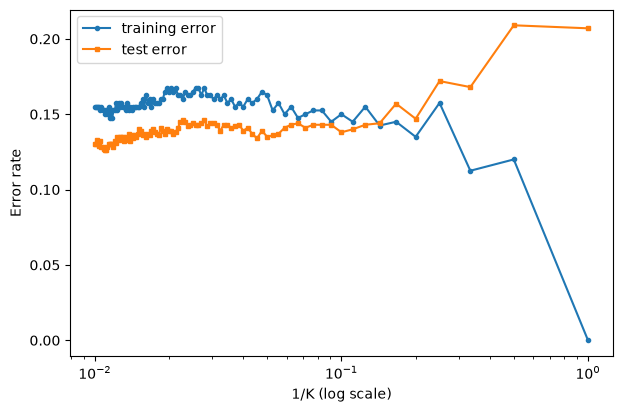

In [48]:
inv_K = 1 / np.array(Ks)
fig, ax = subplots(figsize=(7, 4.5))
ax.plot(inv_K, train_err, 'o-', ms=3, label='training error')
ax.plot(inv_K, test_err, 's-', ms=3, label='test error')
ax.set_xscale('log')
ax.set_xlabel('1/K (log scale)'); ax.set_ylabel('Error rate'); ax.legend()

In [49]:
best = int(np.argmin(test_err))
print(f"Best K = {Ks[best]}, test error = {test_err[best]:.3f}")

Best K = 90, test error = 0.126
